# Fine-tuning Evaluation Notebook

> 현업 표준 파인튜닝 평가 시스템

## 평가 메트릭

### SQL Agent
- **Execution Accuracy (EX)**: SQL이 에러 없이 실행되는 비율
- **Result Accuracy**: 실행 결과가 정답과 일치하는 비율

### RAG Agent
- **Keyword Match**: 기대 키워드 포함 비율
- **LLM-as-Judge**: 1-5점 품질 평가 (CoT 추론)

### 통계 검증
- **Wilcoxon Signed-Rank Test**: p < 0.05 시 유의미한 차이

## 1. Setup & Configuration

In [1]:
# 의존성 설치 (필요시 주석 해제)
!pip install scipy matplotlib seaborn pandas tabulate

In [2]:
import sys
import os
import json
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional
import warnings
warnings.filterwarnings('ignore')

# 프로젝트 루트 설정
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")

Project Root: C:\workspace\enterprise-hr-agent


In [5]:
# 환경 설정
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

# 모델 설정
BASE_MODEL = "qwen3:8b"           # 베이스 모델
FINETUNED_MODEL = "qwen3-hr"      # 파인튜닝 모델 (없으면 BASE_MODEL 사용)
PROVIDER = "ollama"
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

print(f"Base Model: {BASE_MODEL}")
print(f"Fine-tuned Model: {FINETUNED_MODEL}")
print(f"Ollama URL: {OLLAMA_BASE_URL}")

Base Model: qwen3:8b
Fine-tuned Model: qwen3-hr
Ollama URL: http://localhost:11434


In [6]:
# 시각화 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 스타일
plt.style.use('seaborn-v0_8-whitegrid')

# 색상 팔레트
COLORS = {
    'base': '#3498db',      # 파란색
    'finetuned': '#e74c3c', # 빨간색
    'success': '#2ecc71',   # 녹색
    'fail': '#95a5a6'       # 회색
}

## 2. 테스트 데이터 로드

In [7]:
# 테스트 데이터 로드
DATA_DIR = PROJECT_ROOT / "data" / "finetuning"

with open(DATA_DIR / "sql_test.json", "r", encoding="utf-8") as f:
    sql_test_cases = json.load(f)

with open(DATA_DIR / "rag_test.json", "r", encoding="utf-8") as f:
    rag_test_cases = json.load(f)

print(f"SQL 테스트 케이스: {len(sql_test_cases)}개")
print(f"RAG 테스트 케이스: {len(rag_test_cases)}개")

SQL 테스트 케이스: 10개
RAG 테스트 케이스: 10개


In [8]:
# 테스트 데이터 미리보기
import pandas as pd

# SQL 테스트셋
sql_df = pd.DataFrame(sql_test_cases)
print("=== SQL 테스트셋 ===")
display(sql_df[['id', 'question', 'category']])

=== SQL 테스트셋 ===


,id,question,category
0,1,영업팀에서 가장 높은 급여를 받는 사람은?,aggregation_join
1,2,과장 직급의 평균 급여는 얼마야?,aggregation_filter
2,3,2024년 1월 3일에 지각한 직원 명단,join_filter
3,4,현재 휴직 중인 직원은 누구야?,simple_filter
4,5,평가 점수가 4.5 이상인 우수 직원 목록,join_filter_sort
5,6,보너스 총액이 가장 큰 부서는?,aggregation_group
6,7,2020년 이후에 입사한 직원은 몇 명이야?,count_filter
7,8,인사팀 대리의 급여 정보 알려줘,multi_filter_join
8,9,가장 오래 근무한 직원은 누구야?,sort_limit
9,10,부서별 평균 평가 점수를 알려줘,aggregation_group_join


In [9]:
# RAG 테스트셋
rag_df = pd.DataFrame(rag_test_cases)
print("=== RAG 테스트셋 ===")
display(rag_df[['id', 'question', 'category']])

=== RAG 테스트셋 ===


,id,question,category
0,1,병가는 어떻게 사용하나요?,policy_lookup
1,2,육아휴직은 얼마 동안 쓸 수 있어?,policy_lookup
2,3,정직 징계가 뭐야?,term_definition
3,4,재택근무는 어떻게 하는 거야?,policy_lookup
4,5,연장근로 수당은 어떻게 계산해?,calculation
5,6,경조사휴가 종류 알려줘,policy_lookup
6,7,수습기간이 뭐야?,term_definition
7,8,복지포인트는 어디에 쓸 수 있어?,benefit_lookup
8,9,안식휴가는 언제 받을 수 있어?,policy_lookup
9,10,회사 VPN은 뭐야?,term_definition


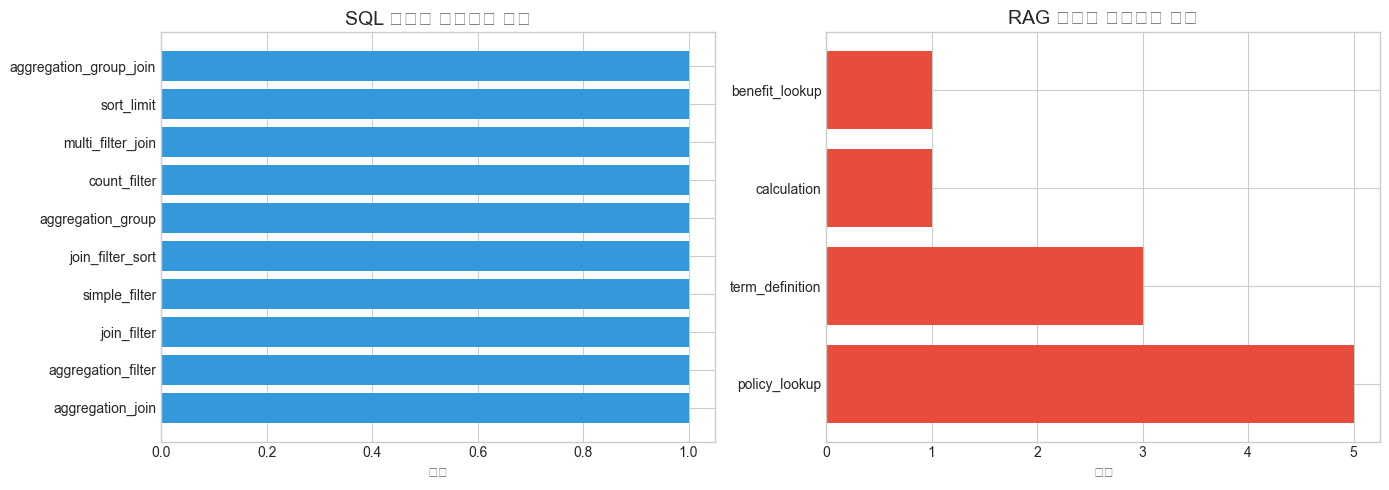

In [10]:
# 카테고리 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SQL 카테고리
sql_cats = sql_df['category'].value_counts()
axes[0].barh(sql_cats.index, sql_cats.values, color=COLORS['base'])
axes[0].set_title('SQL 테스트 카테고리 분포', fontsize=14)
axes[0].set_xlabel('개수')

# RAG 카테고리
rag_cats = rag_df['category'].value_counts()
axes[1].barh(rag_cats.index, rag_cats.values, color=COLORS['finetuned'])
axes[1].set_title('RAG 테스트 카테고리 분포', fontsize=14)
axes[1].set_xlabel('개수')

plt.tight_layout()
plt.show()

## 3. SQL Agent 평가

In [11]:
# Agent 및 DB 로드
from core.agents.sql_agent import SQLAgent
from core.database.connection import DatabaseConnection

# DB 연결 (환경변수에서 URL 가져오기)
DATABASE_URL = os.getenv("DATABASE_URL")
db = DatabaseConnection(DATABASE_URL)

print(f"DB 연결 성공: {DATABASE_URL.split('@')[1] if '@' in DATABASE_URL else DATABASE_URL}")

DB 연결 성공: localhost:3306/enterprise_hr_db


In [15]:
@dataclass
class SQLEvalResult:
    """SQL 평가 결과"""
    question: str
    category: str
    expected_sql: str
    generated_sql: str
    execution_success: bool
    result_match: bool
    error: Optional[str] = None


def safe_parse_response(response: Any) -> dict:
    """Agent 응답을 안전하게 파싱"""
    if response is None:
        return {"success": False, "answer": "", "metadata": {}, "error": "Response is None"}
    
    if isinstance(response, dict):
        return response
    
    # TypedDict나 다른 타입인 경우 dict로 변환 시도
    try:
        return dict(response)
    except:
        return {"success": False, "answer": "", "metadata": {}, "error": f"Cannot parse {type(response)}"}


def compare_results(generated: List[Dict], expected: List[Dict]) -> bool:
    """SQL 결과 비교 (순서 무관, 숫자 ±1% 허용)"""
    if generated is None or expected is None:
        return False
    
    # 리스트가 아닌 경우 처리
    if not isinstance(generated, list) or not isinstance(expected, list):
        return str(generated) == str(expected)
    
    if len(generated) != len(expected):
        return False
    
    # 빈 결과
    if len(generated) == 0:
        return True
    
    # 각 row를 문자열로 변환 후 정렬 비교
    try:
        def row_to_str(row):
            """row를 비교 가능한 문자열로 변환"""
            if isinstance(row, dict):
                # dict인 경우 키 정렬 후 문자열화
                return str(sorted(row.items()))
            else:
                # tuple, list 등 다른 타입
                return str(row)
        
        gen_sorted = sorted([row_to_str(row) for row in generated])
        exp_sorted = sorted([row_to_str(row) for row in expected])
        
        return gen_sorted == exp_sorted
    except Exception as e:
        print(f"  비교 오류: {e}")
        # 폴백: 단순 문자열 비교
        return str(generated) == str(expected)

In [16]:
def evaluate_sql_agent(model: str, test_cases: List[Dict], db: DatabaseConnection) -> Dict[str, Any]:
    """SQL Agent 평가 실행"""
    print(f"\n{'='*60}")
    print(f"SQL Agent 평가: {model}")
    print(f"{'='*60}")
    
    # Agent 초기화
    try:
        agent = SQLAgent(
            db=db,  # DB 연결 주입
            provider=PROVIDER,
            model=model,
            base_url=OLLAMA_BASE_URL,
            max_attempts=3
        )
    except Exception as e:
        print(f"Agent 초기화 실패: {e}")
        return {"error": str(e), "results": [], "metrics": {}}
    
    results = []
    execution_success_count = 0
    result_match_count = 0
    
    for i, case in enumerate(test_cases):
        print(f"\n[{case['id']}] {case['question'][:50]}...")
        
        try:
            # Agent 호출
            response = agent.query(case["question"])
            parsed = safe_parse_response(response)
            
            # SQL 추출
            metadata = parsed.get("metadata", {}) or {}
            generated_sql = metadata.get("sql", "")
            
            print(f"  SQL: {generated_sql[:60]}..." if generated_sql else "  SQL: (없음)")
            
            # SQL 실행
            execution_success = False
            result_match = False
            generated_result = None
            error_msg = None
            
            if generated_sql:
                try:
                    # 튜플 언패킹: (결과, 에러)
                    generated_result, exec_error = db.execute_query(generated_sql)
                    if exec_error:
                        execution_success = False
                        error_msg = exec_error
                        print(f"  실행: ✗ 실패 ({error_msg[:50]})")
                    else:
                        execution_success = True
                        print(f"  실행: ✓ 성공")
                except Exception as e:
                    error_msg = str(e)
                    print(f"  실행: ✗ 예외 ({error_msg[:50]})")
            
            # 정답과 비교
            if execution_success and generated_result is not None:
                try:
                    # 튜플 언패킹: (결과, 에러)
                    expected_result, exp_error = db.execute_query(case["expected_sql"])
                    if exp_error:
                        print(f"  정답 SQL 실행 실패: {exp_error}")
                    else:
                        result_match = compare_results(generated_result, expected_result)
                        print(f"  결과 일치: {'✓' if result_match else '✗'}")
                except Exception as e:
                    print(f"  정답 SQL 실행 예외: {e}")
            
            if execution_success:
                execution_success_count += 1
            if result_match:
                result_match_count += 1
            
            results.append(SQLEvalResult(
                question=case["question"],
                category=case["category"],
                expected_sql=case["expected_sql"],
                generated_sql=generated_sql,
                execution_success=execution_success,
                result_match=result_match,
                error=error_msg
            ))
            
        except Exception as e:
            print(f"  에러: {e}")
            results.append(SQLEvalResult(
                question=case["question"],
                category=case["category"],
                expected_sql=case["expected_sql"],
                generated_sql="",
                execution_success=False,
                result_match=False,
                error=str(e)
            ))
    
    # 메트릭 계산
    total = len(test_cases)
    metrics = {
        "execution_accuracy": execution_success_count / total * 100,
        "result_accuracy": result_match_count / total * 100,
        "execution_success_count": execution_success_count,
        "result_match_count": result_match_count,
        "total": total
    }
    
    print(f"\n{'='*60}")
    print(f"결과: 실행 성공률 {metrics['execution_accuracy']:.1f}%, 결과 정확도 {metrics['result_accuracy']:.1f}%")
    
    return {
        "model": model,
        "metrics": metrics,
        "results": [asdict(r) for r in results]
    }

In [17]:
# Base 모델 평가
sql_base_results = evaluate_sql_agent(BASE_MODEL, sql_test_cases, db)


SQL Agent 평가: qwen3:8b

[1] 영업팀에서 가장 높은 급여를 받는 사람은?...
  SQL: SELECT e.name
FROM employees e
JOIN departments d ON e.dept_...
  실행: ✓ 성공
  결과 일치: ✗

[2] 과장 직급의 평균 급여는 얼마야?...
  SQL: SELECT AVG(s.base_salary) FROM employees e JOIN salaries s O...
  실행: ✓ 성공
  결과 일치: ✗

[3] 2024년 1월 3일에 지각한 직원 명단...
  SQL: SELECT employees.name 
FROM employees 
JOIN attendance ON em...
  실행: ✓ 성공
  결과 일치: ✓

[4] 현재 휴직 중인 직원은 누구야?...
  SQL: SELECT name FROM employees WHERE status = 'LEAVE';...
  실행: ✓ 성공
  결과 일치: ✗

[5] 평가 점수가 4.5 이상인 우수 직원 목록...
  SQL: SELECT employees.name, evaluations.score
FROM evaluations
JO...
  실행: ✓ 성공
  결과 일치: ✓

[6] 보너스 총액이 가장 큰 부서는?...
  SQL: SELECT departments.name, SUM(salaries.bonus) 
FROM salaries ...
  실행: ✓ 성공
  결과 일치: ✗

[7] 2020년 이후에 입사한 직원은 몇 명이야?...
  SQL: SELECT COUNT(*) FROM employees WHERE join_date > '2020-01-01...
  실행: ✓ 성공
  결과 일치: ✗

[8] 인사팀 대리의 급여 정보 알려줘...
  SQL: SELECT salaries.base_salary, salaries.bonus, salaries.paymen...
  실행: ✓ 성공
  결과 일치: ✗

[9] 가장 오

In [18]:
# Fine-tuned 모델 평가 (모델이 있는 경우만)
# 없으면 Base 결과 복사 (비교 시각화용)

try:
    sql_ft_results = evaluate_sql_agent(FINETUNED_MODEL, sql_test_cases, db)
except Exception as e:
    print(f"Fine-tuned 모델 없음: {e}")
    print("Base 모델 결과를 복사합니다.")
    sql_ft_results = sql_base_results.copy()
    sql_ft_results["model"] = FINETUNED_MODEL


SQL Agent 평가: qwen3-hr

[1] 영업팀에서 가장 높은 급여를 받는 사람은?...
  SQL: SELECT e.name, s.base_salary FROM employees e JOIN departmen...
  실행: ✓ 성공
  결과 일치: ✓

[2] 과장 직급의 평균 급여는 얼마야?...
  SQL: SELECT AVG(s.base_salary) as avg_salary FROM salaries s JOIN...
  실행: ✓ 성공
  결과 일치: ✓

[3] 2024년 1월 3일에 지각한 직원 명단...
  SQL: SELECT e.name FROM attendance a JOIN employees e ON a.emp_id...
  실행: ✓ 성공
  결과 일치: ✓

[4] 현재 휴직 중인 직원은 누구야?...
  SQL: SELECT e.name FROM employees e WHERE e.status = 'LEAVE';...
  실행: ✓ 성공
  결과 일치: ✗

[5] 평가 점수가 4.5 이상인 우수 직원 목록...
  SQL: SELECT e.name FROM evaluations ev JOIN employees e ON ev.emp...
  실행: ✓ 성공
  결과 일치: ✗

[6] 보너스 총액이 가장 큰 부서는?...
  SQL: SELECT d.name, SUM(s.bonus) as total_bonus FROM salaries s J...
  실행: ✓ 성공
  결과 일치: ✓

[7] 2020년 이후에 입사한 직원은 몇 명이야?...
  SQL: SELECT COUNT(*) as count FROM employees WHERE join_date >= '...
  실행: ✓ 성공
  결과 일치: ✓

[8] 인사팀 대리의 급여 정보 알려줘...
  SQL: SELECT s.base_salary, s.bonus, s.payment_date FROM salaries ...
  실행: ✓ 성공
  결과 일치: ✗

[9

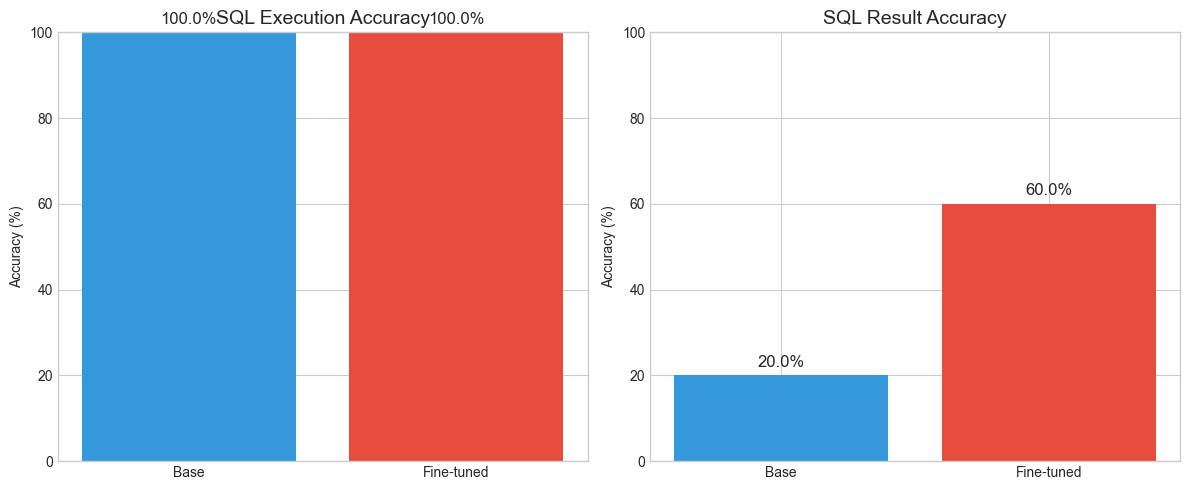

In [19]:
# SQL 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Execution Accuracy 비교
models = ['Base', 'Fine-tuned']
exec_acc = [
    sql_base_results['metrics']['execution_accuracy'],
    sql_ft_results['metrics']['execution_accuracy']
]
colors = [COLORS['base'], COLORS['finetuned']]

bars1 = axes[0].bar(models, exec_acc, color=colors)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('SQL Execution Accuracy', fontsize=14)
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, exec_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val:.1f}%', ha='center', fontsize=12)

# 2. Result Accuracy 비교
result_acc = [
    sql_base_results['metrics']['result_accuracy'],
    sql_ft_results['metrics']['result_accuracy']
]

bars2 = axes[1].bar(models, result_acc, color=colors)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('SQL Result Accuracy', fontsize=14)
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, result_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## 4. RAG Agent 평가

In [20]:
from core.agents.rag_agent import RAGAgent

@dataclass
class RAGEvalResult:
    """RAG 평가 결과"""
    question: str
    category: str
    generated_answer: str
    ground_truth: str
    keyword_match_count: int
    keyword_total: int
    keyword_match_rate: float
    llm_score: int  # 1-5
    is_grounded: bool
    error: Optional[str] = None

In [21]:
def llm_as_judge(question: str, answer: str, ground_truth: str, 
                 judge_model: str = BASE_MODEL) -> Dict[str, Any]:
    """
    LLM-as-Judge: Chain-of-Thought 추론 기반 평가
    
    Returns:
        {"score": 1-5, "is_grounded": bool, "explanation": str}
    """
    from core.llm.factory import create_chat_model
    
    llm = create_chat_model(
        provider=PROVIDER,
        model=judge_model,
        temperature=0,
        base_url=OLLAMA_BASE_URL
    )
    
    prompt = f"""You are an expert evaluator for a Korean HR chatbot.

## Question
{question}

## Generated Answer
{answer}

## Ground Truth
{ground_truth}

## Evaluation Criteria (1-5 scale):
1점: 완전히 틀림 또는 답변 없음
2점: 일부 관련 있지만 주요 정보 누락
3점: 부분적으로 정확, 보완 필요
4점: 대부분 정확, 사소한 누락
5점: 완벽하게 정확하고 완전함

## Instructions:
Think step by step:
1. Ground Truth의 핵심 정보 식별
2. Generated Answer에 포함된 정보 확인
3. 누락되거나 잘못된 정보 확인
4. 최종 점수 결정

Output JSON only (no markdown):
{{"score": <1-5>, "is_grounded": <true/false>, "explanation": "<한국어 설명>"}}
"""
    
    try:
        response = llm.invoke(prompt)
        content = response.content.strip()
        
        # JSON 추출
        if "```json" in content:
            content = content.split("```json")[1].split("```")[0]
        elif "```" in content:
            content = content.split("```")[1].split("```")[0]
        
        # JSON 파싱
        result = json.loads(content.strip())
        return {
            "score": int(result.get("score", 3)),
            "is_grounded": bool(result.get("is_grounded", False)),
            "explanation": result.get("explanation", "")
        }
        
    except Exception as e:
        print(f"  LLM Judge 에러: {e}")
        return {"score": 1, "is_grounded": False, "explanation": f"Error: {e}"}

In [22]:
def evaluate_rag_agent(model: str, test_cases: List[Dict]) -> Dict[str, Any]:
    """RAG Agent 평가 실행"""
    print(f"\n{'='*60}")
    print(f"RAG Agent 평가: {model}")
    print(f"{'='*60}")
    
    # Agent 초기화
    try:
        agent = RAGAgent(
            provider=PROVIDER,
            model=model,
            base_url=OLLAMA_BASE_URL,
            top_k=3
        )
    except Exception as e:
        print(f"Agent 초기화 실패: {e}")
        return {"error": str(e), "results": [], "metrics": {}}
    
    results = []
    total_keyword_match = 0
    total_keywords = 0
    total_llm_score = 0
    grounded_count = 0
    
    for case in test_cases:
        print(f"\n[{case['id']}] {case['question'][:50]}...")
        
        try:
            # Agent 호출
            response = agent.query(case["question"])
            parsed = safe_parse_response(response)
            
            generated_answer = parsed.get("answer", "") or ""
            print(f"  답변: {generated_answer[:60]}..." if generated_answer else "  답변: (없음)")
            
            # 키워드 매칭
            expected_keywords = case.get("expected_keywords", [])
            matched = sum(1 for kw in expected_keywords if kw.lower() in generated_answer.lower())
            match_rate = matched / len(expected_keywords) if expected_keywords else 0
            print(f"  키워드: {matched}/{len(expected_keywords)} ({match_rate*100:.0f}%)")
            
            # LLM-as-Judge
            judge_result = llm_as_judge(
                case["question"], 
                generated_answer, 
                case["ground_truth"]
            )
            print(f"  LLM 점수: {judge_result['score']}/5 (근거: {'✓' if judge_result['is_grounded'] else '✗'})")
            
            # 집계
            total_keyword_match += matched
            total_keywords += len(expected_keywords)
            total_llm_score += judge_result['score']
            if judge_result['is_grounded']:
                grounded_count += 1
            
            results.append(RAGEvalResult(
                question=case["question"],
                category=case["category"],
                generated_answer=generated_answer,
                ground_truth=case["ground_truth"],
                keyword_match_count=matched,
                keyword_total=len(expected_keywords),
                keyword_match_rate=match_rate,
                llm_score=judge_result['score'],
                is_grounded=judge_result['is_grounded']
            ))
            
        except Exception as e:
            print(f"  에러: {e}")
            results.append(RAGEvalResult(
                question=case["question"],
                category=case["category"],
                generated_answer="",
                ground_truth=case["ground_truth"],
                keyword_match_count=0,
                keyword_total=len(case.get("expected_keywords", [])),
                keyword_match_rate=0,
                llm_score=1,
                is_grounded=False,
                error=str(e)
            ))
    
    # 메트릭 계산
    total = len(test_cases)
    metrics = {
        "avg_keyword_match_rate": total_keyword_match / total_keywords * 100 if total_keywords else 0,
        "avg_llm_score": total_llm_score / total,
        "grounded_rate": grounded_count / total * 100,
        "total": total
    }
    
    print(f"\n{'='*60}")
    print(f"결과: 키워드 {metrics['avg_keyword_match_rate']:.1f}%, LLM {metrics['avg_llm_score']:.2f}/5, 근거율 {metrics['grounded_rate']:.1f}%")
    
    return {
        "model": model,
        "metrics": metrics,
        "results": [asdict(r) for r in results]
    }

In [23]:
# Base 모델 평가
rag_base_results = evaluate_rag_agent(BASE_MODEL, rag_test_cases)


RAG Agent 평가: qwen3:8b

[1] 병가는 어떻게 사용하나요?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[2] 육아휴직은 얼마 동안 쓸 수 있어?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[3] 정직 징계가 뭐야?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[4] 재택근무는 어떻게 하는 거야?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[5] 연장근로 수당은 어떻게 계산해?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[6] 경조사휴가 종류 알려줘...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[7] 수습기간이 뭐야?...
  답변: (없음)
  키워드: 0/5 (0%)
  LLM 점수: 1/5 (근거: ✗)

[8] 복지포인트는 어디에 쓸 수 있어?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[9] 안식휴가는 언제 받을 수 있어?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[10] 회사 VPN은 뭐야?...
  답변: (없음)
  키워드: 0/5 (0%)
  LLM 점수: 1/5 (근거: ✗)

결과: 키워드 0.0%, LLM 1.00/5, 근거율 0.0%


In [24]:
# Fine-tuned 모델 평가
try:
    rag_ft_results = evaluate_rag_agent(FINETUNED_MODEL, rag_test_cases)
except Exception as e:
    print(f"Fine-tuned 모델 없음: {e}")
    rag_ft_results = rag_base_results.copy()
    rag_ft_results["model"] = FINETUNED_MODEL


RAG Agent 평가: qwen3-hr

[1] 병가는 어떻게 사용하나요?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[2] 육아휴직은 얼마 동안 쓸 수 있어?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[3] 정직 징계가 뭐야?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[4] 재택근무는 어떻게 하는 거야?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[5] 연장근로 수당은 어떻게 계산해?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[6] 경조사휴가 종류 알려줘...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[7] 수습기간이 뭐야?...
  답변: (없음)
  키워드: 0/5 (0%)
  LLM 점수: 1/5 (근거: ✗)

[8] 복지포인트는 어디에 쓸 수 있어?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[9] 안식휴가는 언제 받을 수 있어?...
  답변: (없음)
  키워드: 0/4 (0%)
  LLM 점수: 1/5 (근거: ✗)

[10] 회사 VPN은 뭐야?...
  답변: (없음)
  키워드: 0/5 (0%)
  LLM 점수: 1/5 (근거: ✗)

결과: 키워드 0.0%, LLM 1.00/5, 근거율 0.0%


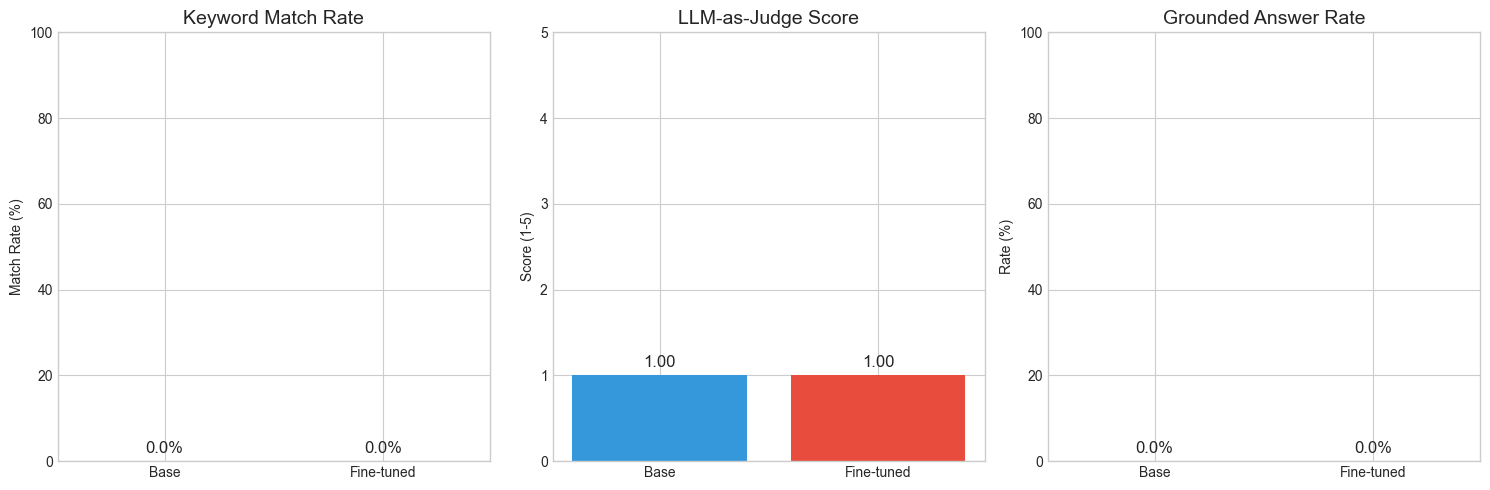

In [25]:
# RAG 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Base', 'Fine-tuned']
colors = [COLORS['base'], COLORS['finetuned']]

# 1. Keyword Match Rate
kw_rates = [
    rag_base_results['metrics']['avg_keyword_match_rate'],
    rag_ft_results['metrics']['avg_keyword_match_rate']
]
bars1 = axes[0].bar(models, kw_rates, color=colors)
axes[0].set_ylabel('Match Rate (%)')
axes[0].set_title('Keyword Match Rate', fontsize=14)
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, kw_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val:.1f}%', ha='center', fontsize=12)

# 2. LLM Score
llm_scores = [
    rag_base_results['metrics']['avg_llm_score'],
    rag_ft_results['metrics']['avg_llm_score']
]
bars2 = axes[1].bar(models, llm_scores, color=colors)
axes[1].set_ylabel('Score (1-5)')
axes[1].set_title('LLM-as-Judge Score', fontsize=14)
axes[1].set_ylim(0, 5)
for bar, val in zip(bars2, llm_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{val:.2f}', ha='center', fontsize=12)

# 3. Grounded Rate
grounded_rates = [
    rag_base_results['metrics']['grounded_rate'],
    rag_ft_results['metrics']['grounded_rate']
]
bars3 = axes[2].bar(models, grounded_rates, color=colors)
axes[2].set_ylabel('Rate (%)')
axes[2].set_title('Grounded Answer Rate', fontsize=14)
axes[2].set_ylim(0, 100)
for bar, val in zip(bars3, grounded_rates):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## 5. 통계적 유의성 검증

In [26]:
from scipy.stats import wilcoxon
import numpy as np

def statistical_significance_test(base_scores: List[float], ft_scores: List[float], 
                                   metric_name: str = "Score") -> Dict[str, Any]:
    """
    Wilcoxon Signed-Rank Test for paired samples
    
    - 비모수 검정 (정규분포 가정 불필요)
    - 쌍대 비교에 적합 (동일 질문에 대한 두 모델 점수)
    """
    base = np.array(base_scores)
    ft = np.array(ft_scores)
    
    # 동일한 경우 처리
    if np.allclose(base, ft):
        return {
            "metric": metric_name,
            "base_mean": float(np.mean(base)),
            "ft_mean": float(np.mean(ft)),
            "difference": 0.0,
            "statistic": 0.0,
            "p_value": 1.0,
            "is_significant": False,
            "interpretation": "두 모델 간 차이 없음 (동일 점수)"
        }
    
    try:
        stat, p_value = wilcoxon(base, ft, alternative='two-sided')
    except ValueError as e:
        return {
            "metric": metric_name,
            "base_mean": float(np.mean(base)),
            "ft_mean": float(np.mean(ft)),
            "difference": float(np.mean(ft) - np.mean(base)),
            "statistic": 0.0,
            "p_value": 1.0,
            "is_significant": False,
            "interpretation": f"검정 실패: {e}"
        }
    
    is_significant = p_value < 0.05
    mean_diff = np.mean(ft) - np.mean(base)
    
    if is_significant:
        if mean_diff > 0:
            interpretation = f"✓ Fine-tuned 모델이 유의미하게 우수 (p={p_value:.4f})"
        else:
            interpretation = f"✗ Base 모델이 유의미하게 우수 (p={p_value:.4f})"
    else:
        interpretation = f"△ 유의미한 차이 없음 (p={p_value:.4f})"
    
    return {
        "metric": metric_name,
        "base_mean": float(np.mean(base)),
        "ft_mean": float(np.mean(ft)),
        "difference": float(mean_diff),
        "statistic": float(stat),
        "p_value": float(p_value),
        "is_significant": is_significant,
        "interpretation": interpretation
    }

In [27]:
# SQL 통계 검증
sql_base_exec = [1 if r['execution_success'] else 0 for r in sql_base_results['results']]
sql_ft_exec = [1 if r['execution_success'] else 0 for r in sql_ft_results['results']]

sql_stat_result = statistical_significance_test(sql_base_exec, sql_ft_exec, "SQL Execution")

print("=" * 60)
print("SQL Agent 통계 검증")
print("=" * 60)
print(f"Base 평균: {sql_stat_result['base_mean']:.2f}")
print(f"Fine-tuned 평균: {sql_stat_result['ft_mean']:.2f}")
print(f"차이: {sql_stat_result['difference']:+.2f}")
print(f"p-value: {sql_stat_result['p_value']:.4f}")
print(f"결론: {sql_stat_result['interpretation']}")

SQL Agent 통계 검증
Base 평균: 1.00
Fine-tuned 평균: 1.00
차이: +0.00
p-value: 1.0000
결론: 두 모델 간 차이 없음 (동일 점수)


In [28]:
# RAG 통계 검증 (LLM Score 기준)
rag_base_scores = [r['llm_score'] for r in rag_base_results['results']]
rag_ft_scores = [r['llm_score'] for r in rag_ft_results['results']]

rag_stat_result = statistical_significance_test(rag_base_scores, rag_ft_scores, "RAG LLM Score")

print("=" * 60)
print("RAG Agent 통계 검증")
print("=" * 60)
print(f"Base 평균: {rag_stat_result['base_mean']:.2f}")
print(f"Fine-tuned 평균: {rag_stat_result['ft_mean']:.2f}")
print(f"차이: {rag_stat_result['difference']:+.2f}")
print(f"p-value: {rag_stat_result['p_value']:.4f}")
print(f"결론: {rag_stat_result['interpretation']}")

RAG Agent 통계 검증
Base 평균: 1.00
Fine-tuned 평균: 1.00
차이: +0.00
p-value: 1.0000
결론: 두 모델 간 차이 없음 (동일 점수)


## 6. 종합 리포트

In [29]:
# Executive Summary 테이블
summary_data = {
    'Metric': [
        'SQL Execution Accuracy',
        'SQL Result Accuracy',
        'RAG Keyword Match',
        'RAG LLM Score',
        'RAG Grounded Rate'
    ],
    'Base': [
        f"{sql_base_results['metrics']['execution_accuracy']:.1f}%",
        f"{sql_base_results['metrics']['result_accuracy']:.1f}%",
        f"{rag_base_results['metrics']['avg_keyword_match_rate']:.1f}%",
        f"{rag_base_results['metrics']['avg_llm_score']:.2f}/5",
        f"{rag_base_results['metrics']['grounded_rate']:.1f}%"
    ],
    'Fine-tuned': [
        f"{sql_ft_results['metrics']['execution_accuracy']:.1f}%",
        f"{sql_ft_results['metrics']['result_accuracy']:.1f}%",
        f"{rag_ft_results['metrics']['avg_keyword_match_rate']:.1f}%",
        f"{rag_ft_results['metrics']['avg_llm_score']:.2f}/5",
        f"{rag_ft_results['metrics']['grounded_rate']:.1f}%"
    ],
    'Δ': [
        f"{sql_ft_results['metrics']['execution_accuracy'] - sql_base_results['metrics']['execution_accuracy']:+.1f}%",
        f"{sql_ft_results['metrics']['result_accuracy'] - sql_base_results['metrics']['result_accuracy']:+.1f}%",
        f"{rag_ft_results['metrics']['avg_keyword_match_rate'] - rag_base_results['metrics']['avg_keyword_match_rate']:+.1f}%",
        f"{rag_ft_results['metrics']['avg_llm_score'] - rag_base_results['metrics']['avg_llm_score']:+.2f}",
        f"{rag_ft_results['metrics']['grounded_rate'] - rag_base_results['metrics']['grounded_rate']:+.1f}%"
    ],
    'Significant': [
        '✓' if sql_stat_result['is_significant'] else '✗',
        '-',  # 결과 정확도는 별도 검증 필요
        '-',
        '✓' if rag_stat_result['is_significant'] else '✗',
        '-'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 70)
print("EXECUTIVE SUMMARY")
print("=" * 70)
display(summary_df)


EXECUTIVE SUMMARY


,Metric,Base,Fine-tuned,Δ,Significant
0,SQL Execution Accuracy,100.0%,100.0%,+0.0%,✗
1,SQL Result Accuracy,20.0%,60.0%,+40.0%,-
2,RAG Keyword Match,0.0%,0.0%,+0.0%,-
3,RAG LLM Score,1.00/5,1.00/5,+0.00,✗
4,RAG Grounded Rate,0.0%,0.0%,+0.0%,-


In [30]:
# 실패 케이스 분석
print("\n" + "=" * 70)
print("FAILURE ANALYSIS")
print("=" * 70)

# SQL 실패 케이스
sql_failures = [r for r in sql_base_results['results'] if not r['execution_success']]
print(f"\n[SQL] 실패 케이스: {len(sql_failures)}개")
for f in sql_failures[:3]:  # 상위 3개만
    print(f"  - {f['question'][:50]}...")
    print(f"    에러: {f.get('error', 'N/A')[:50]}")

# RAG 낮은 점수 케이스
rag_low_scores = [r for r in rag_base_results['results'] if r['llm_score'] <= 2]
print(f"\n[RAG] 낮은 점수 케이스 (≤2점): {len(rag_low_scores)}개")
for r in rag_low_scores[:3]:
    print(f"  - {r['question'][:50]}...")
    print(f"    점수: {r['llm_score']}/5, 키워드: {r['keyword_match_count']}/{r['keyword_total']}")


FAILURE ANALYSIS

[SQL] 실패 케이스: 0개

[RAG] 낮은 점수 케이스 (≤2점): 10개
  - 병가는 어떻게 사용하나요?...
    점수: 1/5, 키워드: 0/4
  - 육아휴직은 얼마 동안 쓸 수 있어?...
    점수: 1/5, 키워드: 0/4
  - 정직 징계가 뭐야?...
    점수: 1/5, 키워드: 0/4


In [31]:
# 결과 저장
evaluation_results = {
    "timestamp": datetime.now().isoformat(),
    "config": {
        "base_model": BASE_MODEL,
        "finetuned_model": FINETUNED_MODEL,
        "provider": PROVIDER
    },
    "sql": {
        "base": sql_base_results,
        "finetuned": sql_ft_results,
        "statistical_test": sql_stat_result
    },
    "rag": {
        "base": rag_base_results,
        "finetuned": rag_ft_results,
        "statistical_test": rag_stat_result
    }
}

# JSON 저장
output_path = DATA_DIR / "evaluation_results.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_results, f, ensure_ascii=False, indent=2, default=str)

print(f"\n결과 저장됨: {output_path}")


결과 저장됨: C:\workspace\enterprise-hr-agent\data\finetuning\evaluation_results.json


In [32]:
# 권장 사항
print("\n" + "=" * 70)
print("RECOMMENDATIONS")
print("=" * 70)

sql_improvement = sql_ft_results['metrics']['execution_accuracy'] - sql_base_results['metrics']['execution_accuracy']
rag_improvement = rag_ft_results['metrics']['avg_llm_score'] - rag_base_results['metrics']['avg_llm_score']

if sql_improvement > 10 and sql_stat_result['is_significant']:
    print("✓ SQL Agent: 파인튜닝 효과 확인, 프로덕션 적용 권장")
elif sql_improvement > 0:
    print("△ SQL Agent: 소폭 개선, 추가 학습 데이터 필요")
else:
    print("✗ SQL Agent: 개선 없음, 학습 데이터/방법 재검토 필요")

if rag_improvement > 0.5 and rag_stat_result['is_significant']:
    print("✓ RAG Agent: 파인튜닝 효과 확인, 프로덕션 적용 권장")
elif rag_improvement > 0:
    print("△ RAG Agent: 소폭 개선, 추가 학습 데이터 필요")
else:
    print("✗ RAG Agent: 개선 없음, 학습 데이터/방법 재검토 필요")

print("\n다음 단계:")
print("1. 실패 케이스를 학습 데이터에 추가")
print("2. 에러 패턴 분석 후 프롬프트 개선")
print("3. Human evaluation으로 추가 검증")


RECOMMENDATIONS
✗ SQL Agent: 개선 없음, 학습 데이터/방법 재검토 필요
✗ RAG Agent: 개선 없음, 학습 데이터/방법 재검토 필요

다음 단계:
1. 실패 케이스를 학습 데이터에 추가
2. 에러 패턴 분석 후 프롬프트 개선
3. Human evaluation으로 추가 검증


---

## 평가 완료

이 노트북은 다음을 제공합니다:

1. **SQL Agent 평가**: Execution Accuracy, Result Accuracy
2. **RAG Agent 평가**: Keyword Match, LLM-as-Judge (1-5점)
3. **통계 검증**: Wilcoxon Signed-Rank Test (p < 0.05)
4. **시각화**: Base vs Fine-tuned 비교 차트
5. **실패 분석**: 개선이 필요한 케이스 식별

결과는 `data/finetuning/evaluation_results.json`에 저장됩니다.